Subjects after full PLS alignment: 175
Merged 175 subjects for 17-net imaging-LV analysis
17-net Pearson r (Seg vs LV1_X) = -0.921 (p = 8.69e-73)
17-net Spearman ρ (Seg vs LV1_X) = -0.955 (p = 7.742e-93)


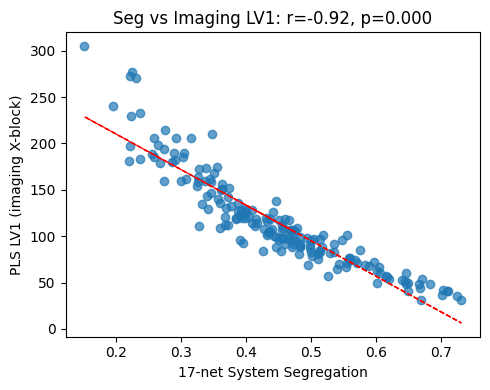

Saved: C:\Users\c3371138\projects\data\raw\export\Results\rest_pls\segregation_vs_LV1X.csv


In [1]:
# %% [IMAGING-LV CORRELATION ONLY]
# Correlate 17-network segregation with IMAGING LV1 (X-block), not behaviour LV1.

import os, pickle
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# ─── SETTINGS ────────────────────────────────────────────────────────────────
base_dir       = r"C:\Users\c3371138\projects\data\raw\export"
data_dir       = os.path.join(base_dir, 'data')
fc_flat_csv    = os.path.join(data_dir, 'all_subjects_flattened.csv')     # X (edges)
behav_csv      = os.path.join(data_dir, 'AF_optical_with_raw_and_zscores.csv')  # for ID alignment only
pls_model_pkl  = os.path.join(base_dir, 'Results','rest_pls','pls_behavioral_model_cleanedXY.pkl')
seg17_csv      = os.path.join(base_dir, 'Results','rest_pls','system_segregation_17net.csv')
remove_ids     = [2001,2102,2198]  # motion-bad etc., must match the PLS workflow
# ─────────────────────────────────────────────────────────────────────────────

# 1) Rebuild the subject list exactly as in the PLS pipeline
#    (so lengths/order match the saved model’s score arrays)
X_df = pd.read_csv(fc_flat_csv, index_col=0)
X_df['record_id'] = X_df.index.map(lambda s: int(s.split('-')[-1]))
X_df = X_df.set_index('record_id')

part = pd.read_csv(behav_csv)
wanted = ['record_id','meatdiet','plantdiet','westerndiet',
          'sbp','dbp','trigs','hdl','glucose','waist']
part = part[wanted]

# Newcastle site only (ID >= 2001), align with available X, complete-case mask
part   = part[part['record_id'] >= 2001]
common = sorted(set(part['record_id']) & set(X_df.index))
X_df   = X_df.loc[common]
part   = part[part['record_id'].isin(common)].sort_values('record_id').reset_index(drop=True)

Y_df   = part.drop(columns='record_id')
X_mat  = X_df.values
Y_mat  = (Y_df - Y_df.mean())/Y_df.std()

mask   = (~np.isnan(Y_mat).any(axis=1)) & (~np.isnan(X_mat).any(axis=1))
final_ids = list(np.array(common)[mask])

# Remove motion-bad (and any other exclusions used in PLS)
final_ids = [rid for rid in final_ids if rid not in remove_ids]
print(f"Subjects after full PLS alignment: {len(final_ids)}")

# 2) Load PLS model & extract IMAGING LV1 (X-block)
pls = pickle.load(open(pls_model_pkl, 'rb'))

# IMPORTANT: use X-block scores (imaging), not Y-block
lv1_x = pls.x_scores[:, 0]
assert len(final_ids) == len(lv1_x), f"{len(final_ids)} IDs vs {len(lv1_x)} imaging LV1 scores"

lv_df = pd.DataFrame({'record_id': final_ids, 'LV1_X': lv1_x})

# 3) Load 17-network segregation & merge to imaging LV1
seg17 = pd.read_csv(seg17_csv)
df17  = seg17.merge(lv_df, on='record_id')

print(f"Merged {len(df17)} subjects for 17-net imaging-LV analysis")

# 4) Correlate segregation with IMAGING LV1
r_p, p_p = pearsonr(df17['segregation'], df17['LV1_X'])
r_s, p_s = spearmanr(df17['segregation'], df17['LV1_X'])
print(f"17-net Pearson r (Seg vs LV1_X) = {r_p:.3f} (p = {p_p:.4g})")
print(f"17-net Spearman ρ (Seg vs LV1_X) = {r_s:.3f} (p = {p_s:.4g})")

# 5) Plot
plt.figure(figsize=(5,4))
plt.scatter(df17['segregation'], df17['LV1_X'], alpha=0.7)
m, b = np.polyfit(df17['segregation'], df17['LV1_X'], 1)
plt.plot(df17['segregation'], m*df17['segregation'] + b, 'r--', lw=1)
plt.xlabel('17-net System Segregation')
plt.ylabel('PLS LV1 (imaging X-block)')
plt.title(f"Seg vs Imaging LV1: r={r_p:.2f}, p={p_p:.3f}")
plt.tight_layout()
plt.show()

# 6) (Optional) Save table for record-keeping
out_csv = os.path.join(base_dir, 'Results','rest_pls','segregation_vs_LV1X.csv')
df17[['record_id','mean_within','mean_between','segregation','LV1_X']].to_csv(out_csv, index=False)
print("Saved:", out_csv)
